### Problem statement:
The objective is to predict whether a bank customer will churn (leave the bank) based on their demographic and account information. Early identification of at-risk customers allows the bank to take proactive retention measures, reducing customer loss and associated revenue impact.

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("Churn_Modelling.csv")

churn = df.copy()

In [3]:
print(f"\n shape of churn datset: {churn.shape}")
print(f"\n columns of churn datset: {churn.columns}")
print(f"\n duplicates in churn datset: {churn.duplicated().sum()}")
print(f"\n missing value in churn datset:\n{churn.isnull().sum()}")
print(f"\n shape of churn datset:\n{churn.dtypes}")
print(f"\n Top 5 data:\n{churn.head()}")


 shape of churn datset: (10000, 14)

 columns of churn datset: Index(['RowNumber', 'CustomerId', 'Surname', 'CreditScore', 'Geography',
       'Gender', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard',
       'IsActiveMember', 'EstimatedSalary', 'Exited'],
      dtype='object')

 duplicates in churn datset: 0

 missing value in churn datset:
RowNumber          0
CustomerId         0
Surname            0
CreditScore        0
Geography          0
Gender             0
Age                0
Tenure             0
Balance            0
NumOfProducts      0
HasCrCard          0
IsActiveMember     0
EstimatedSalary    0
Exited             0
dtype: int64

 shape of churn datset:
RowNumber            int64
CustomerId           int64
Surname             object
CreditScore          int64
Geography           object
Gender              object
Age                  int64
Tenure               int64
Balance            float64
NumOfProducts        int64
HasCrCard            int64
IsActiveMember   

In [4]:
churn["Geography"].value_counts()

Geography
France     5014
Germany    2509
Spain      2477
Name: count, dtype: int64

Observation: Dataset contains 10,000 rows and 14 columns. No missing values or duplicates found. Target variable is 'Exited' — 1 means customer churned, 0 means stayed. Three columns (RowNumber, CustomerId, Surname) are identifiers and carry no predictive value — these will be dropped. Geography (object) and Gender (object) are categorical columns requiring encoding. Remaining columns are numerical.

In [5]:
#droping useless columns
churn = churn.drop(columns=["RowNumber", "CustomerId", "Surname"])

churn.shape

(10000, 11)

we drop row number , customer_id and surname bcz these are unique values and does not help in predicting churn

In [6]:
# seeing statistical summary o numerical columns
print(f"Statistical summary:\n{churn.describe()}")

Statistical summary:
        CreditScore           Age        Tenure        Balance  NumOfProducts  \
count  10000.000000  10000.000000  10000.000000   10000.000000   10000.000000   
mean     650.528800     38.921800      5.012800   76485.889288       1.530200   
std       96.653299     10.487806      2.892174   62397.405202       0.581654   
min      350.000000     18.000000      0.000000       0.000000       1.000000   
25%      584.000000     32.000000      3.000000       0.000000       1.000000   
50%      652.000000     37.000000      5.000000   97198.540000       1.000000   
75%      718.000000     44.000000      7.000000  127644.240000       2.000000   
max      850.000000     92.000000     10.000000  250898.090000       4.000000   

         HasCrCard  IsActiveMember  EstimatedSalary        Exited  
count  10000.00000    10000.000000     10000.000000  10000.000000  
mean       0.70550        0.515100    100090.239881      0.203700  
std        0.45584        0.499797     57510.

In [7]:
## Checking the distribution and value counts of categorical and discrete customer metrics
print(churn["IsActiveMember"].value_counts())
print(churn["HasCrCard"].value_counts())
print(churn["NumOfProducts"].value_counts())
print(churn["Tenure"].value_counts())
print(churn["Exited"].value_counts())

IsActiveMember
1    5151
0    4849
Name: count, dtype: int64
HasCrCard
1    7055
0    2945
Name: count, dtype: int64
NumOfProducts
1    5084
2    4590
3     266
4      60
Name: count, dtype: int64
Tenure
2     1048
1     1035
7     1028
8     1025
5     1012
3     1009
4      989
9      984
6      967
10     490
0      413
Name: count, dtype: int64
Exited
0    7963
1    2037
Name: count, dtype: int64


#### Observation:
5 out of 11 columns are binary or categorical in nature, HasCrCard, IsActiveMember, Exited, NumOfProducts, and Tenure. Credit score, age, balance, and estimated salary are continuous numerical columns.
Credit score is normally distributed. Age is slightly right-skewed with max 92. Balance shows a large gap between mean and median, suggesting many customers have zero balance. Estimated salary is normally distributed.
Almost 50/50 split between active and inactive members. Around 70% customers have a credit card. 90% of customers use only 1–2 bank products. Customers are mostly loyal for 1–8 years, with very few staying beyond that.
Target variable (Exited) is imbalanced — 7,963 (79.6%) stayed and 2,037 (20.4%) churned. This class imbalance will affect model training.

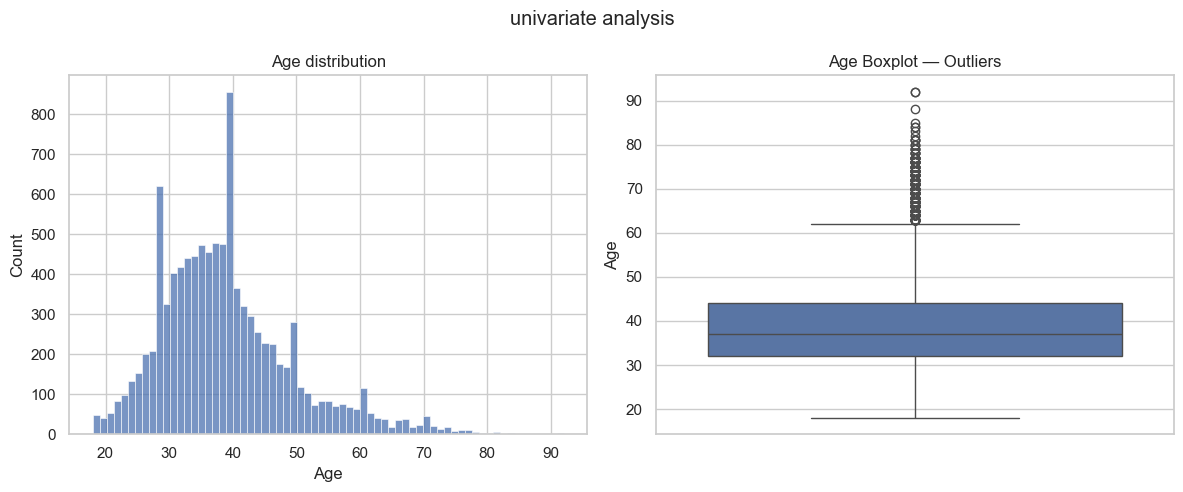

In [8]:
#unvariate analysis of numerical columns
sns.set_theme(style="whitegrid")

fig, axes= plt.subplots(1, 2 , figsize = (12,5))

sns.histplot(data=churn, x="Age", ax=axes[0])
axes[0].set_title("Age distribution")

sns.boxplot(data=churn, y="Age", ax=axes[1])
axes[1].set_title("Age Boxplot — Outliers")

plt.suptitle("univariate analysis")
plt.tight_layout()
plt.show()

##### Observation: Age distribution is right-skewed majority of customers are between 28–45 years with peak around 35–40. Boxplot reveals outliers above 62, suggesting a small group of elderly customers. This age skewness may be relevant to churn analysis.

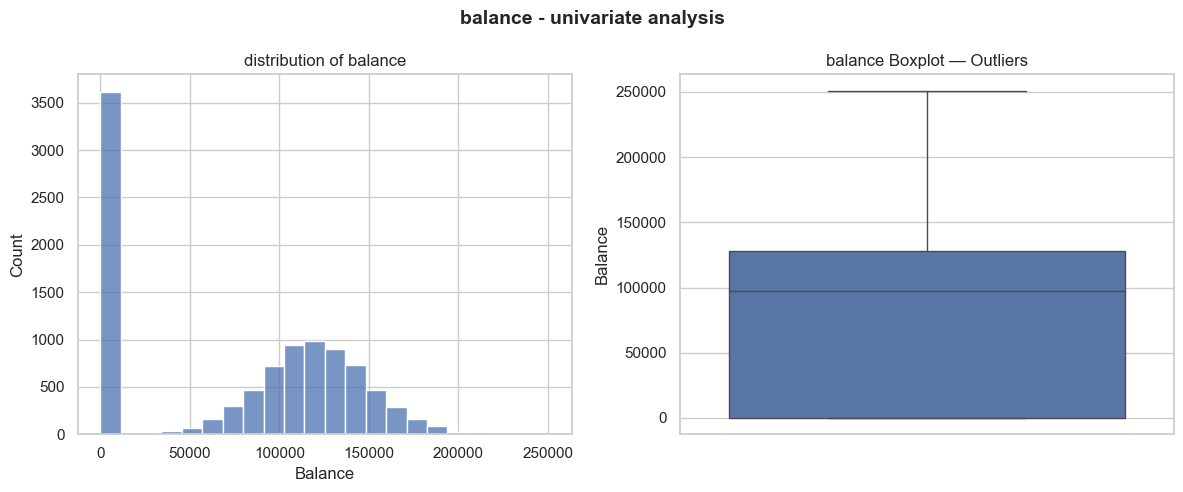

In [9]:
# Univariate analysis of bank balances using a histogram and a boxplot side-by-side
fig, axes = plt.subplots(1, 2,figsize=(12,5))

# Plotting the data distribution
sns.histplot(data=churn, x="Balance", ax=axes[0])
axes[0].set_title("distribution of balance")

# Plotting the boxplot
sns.boxplot(data=churn, y="Balance", ax=axes[1])
axes[1].set_title("balance Boxplot — Outliers")

plt.suptitle("balance - univariate analysis", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

##### Observation: Balance distribution shows a bimodal pattern approximately 3,500 customers have zero balance, while the remaining show a symmetric distribution centered around 120,000–130,000. The boxplot shows no outliers, which is unusual this is because the large number of zero-balance customers pulls the lower whisker to zero, hiding the gap. If zero-balance customers are excluded, the distribution appears nearly normal. These zero-balance accounts may represent inactive customers.

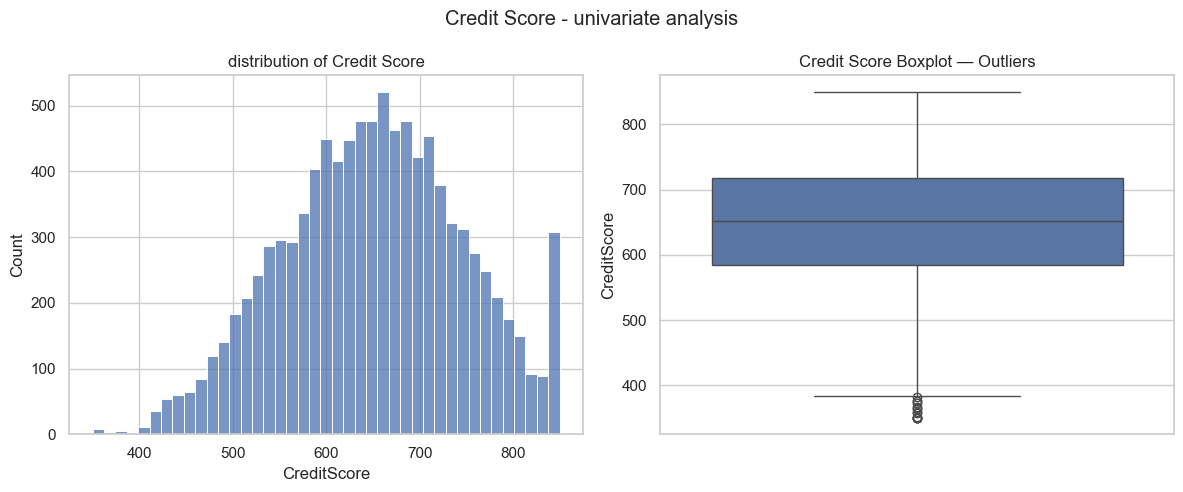

In [10]:
fig, axes = plt.subplots(1, 2,figsize=(12,5))

sns.histplot(data=churn, x="CreditScore", ax=axes[0])
axes[0].set_title("distribution of Credit Score")

sns.boxplot(data=churn, y="CreditScore", ax=axes[1])
axes[1].set_title("Credit Score Boxplot — Outliers")

plt.suptitle("Credit Score - univariate analysis")
plt.tight_layout()
plt.show()

Observation: Credit score distribution is approximately symmetric, centered around 650. However, boxplot reveals outliers below 400, which pull the distribution slightly left-skewed. The spike in the last histogram bin suggests some data irregularity at the higher end. Low credit score outliers may represent high-risk customers worth investigating in bivariate analysis.

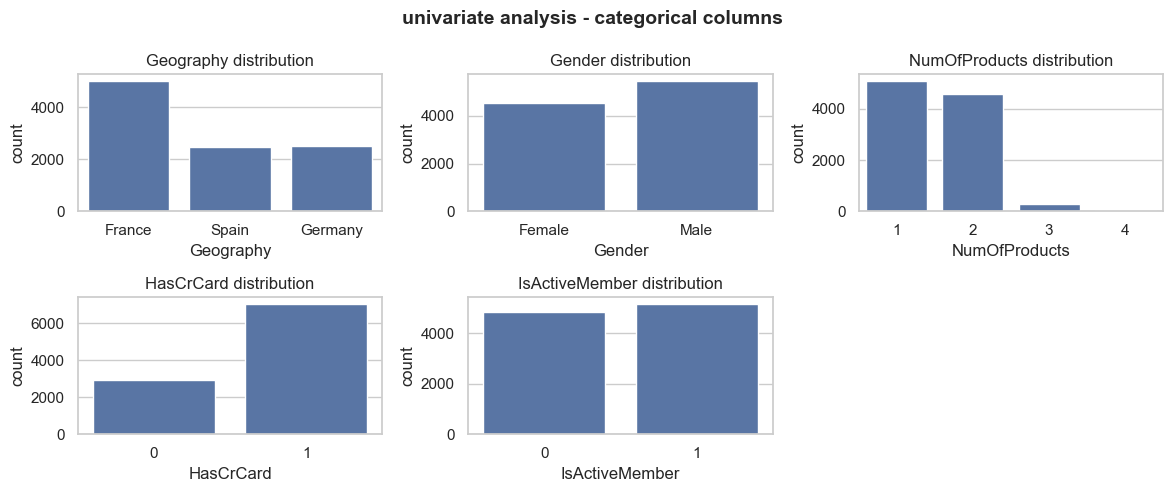

In [21]:
#unvariate analysis of categorical columns using a grid of countplots

categorical_Col = ['Geography', 'Gender', 'NumOfProducts', 'HasCrCard', 'IsActiveMember']

fig, axes = plt.subplots(2, 3, figsize= (12,5))
axes = axes.flatten()

for i, col in enumerate(categorical_Col):
    sns.countplot(data=churn, x= col, ax=axes[i])
    axes[i].set_title(f"{col} distribution")

plt.suptitle(f"univariate analysis - categorical columns", fontsize=14, fontweight='bold')
plt.tight_layout()
axes[5].set_visible(False)
plt.show()

##### Observation: France dominates geography with highest customer count, followed by Germany and Spain. Gender is nearly balanced  ~55% male, ~45% female. Most customers use 1-2 products (90%+), very few use 3-4. Around 70% customers have a credit card. Active and inactive members are almost equal (50-50)."

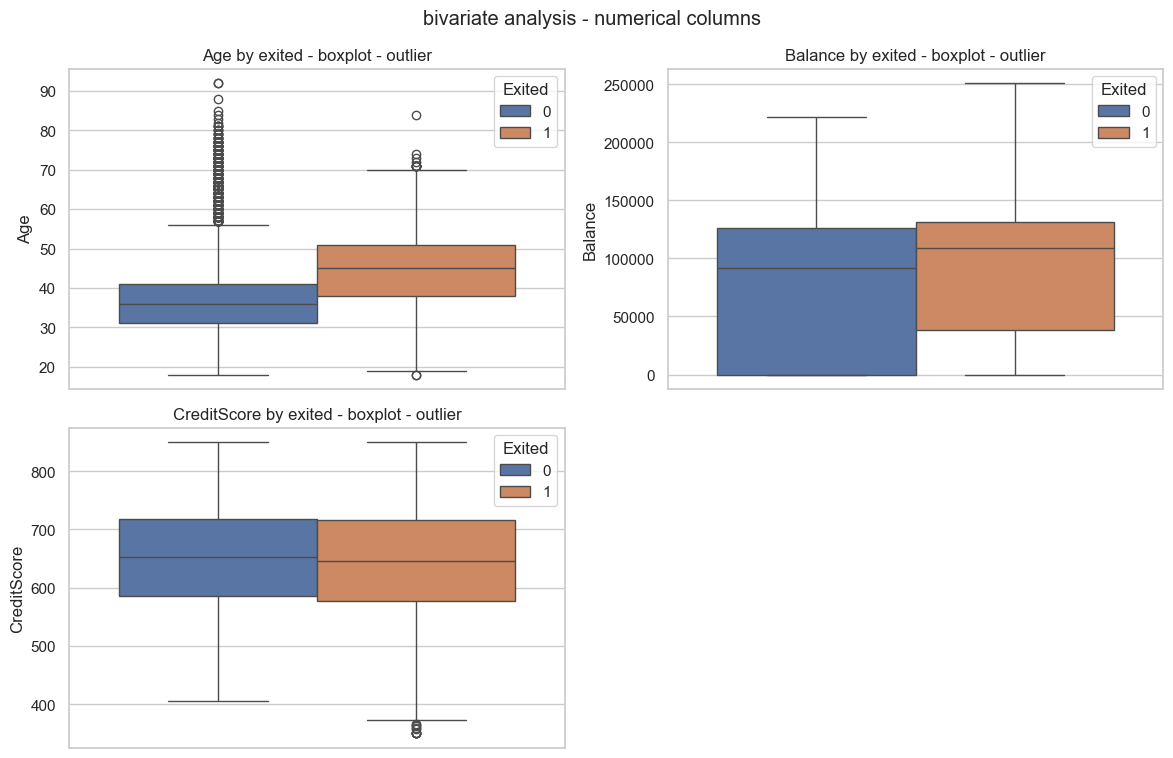

In [ ]:
#bivariate analysis of numerical columns 

numerical_cols = ["Age", "Balance", "CreditScore"]

fig, axes = plt.subplots(2, 2, figsize= (12,8))
axes = axes.flatten()

for i, col in enumerate(numerical_cols):
    sns.boxplot(data=churn, y= col, hue="Exited", ax=axes[i])
    axes[i].set_title(f"{col} by exited - boxplot - outlier")

plt.suptitle("bivariate analysis - numerical columns")
plt.tight_layout()
axes[3].set_visible(False) #remove extra emoty box
plt.show()

##### Observation: Age is the strongest numerical predictor churned customers are significantly older. Balance shows churned customers have higher median balance bank lost valuable customers. Credit score shows no difference between groups not a useful predictor.

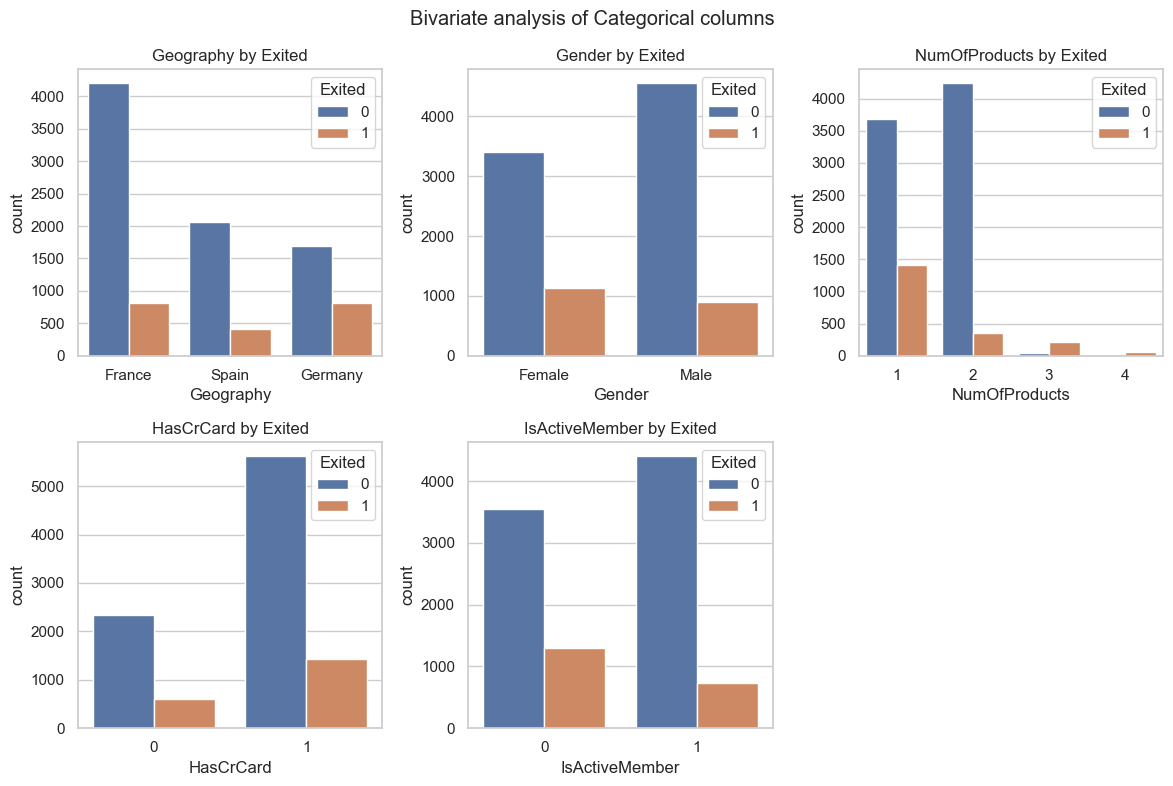

In [13]:
#bivariate analysis of categorical columns
cat_cols_for_bivariate = ["Geography", "Gender", "NumOfProducts", "HasCrCard", "IsActiveMember"]

fig, axes = plt.subplots(2, 3, figsize=(12,8))
axes =axes.flatten()

for i, col in enumerate(cat_cols_for_bivariate):
    sns.countplot(data=churn, x=col, hue="Exited", ax=axes[i])
    axes[i].set_title(f"{col} by Exited")

plt.suptitle("Bivariate analysis of Categorical columns")
plt.tight_layout()
axes[5].set_visible(False)
plt.show()

Observation: Geography: Germany has fewer customers but highest churn rate. France has most customers with moderate churn. Spain has lowest churn rate.
Gender: Females churn more despite being fewer higher female churn rate.
NumOfProducts: 1-product customers churn most. 2-product customers are most loyal. 3-4 product customers almost all churned very suspicious pattern.
HasCrCard: Similar churn in both groups weak signal.
IsActiveMember: Inactive members churn significantly more this is the strongest signal among categorical columns."

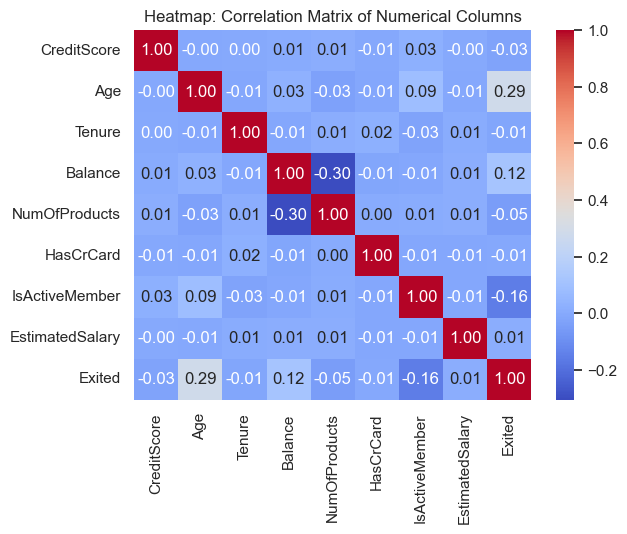

In [27]:
# Bivariate correlation analysis using a heatmap 

sns.heatmap(churn.corr(numeric_only=True), annot=True, fmt='.2f', cmap="coolwarm")
plt.title("Heatmap: Correlation Matrix of Numerical Columns")
plt.show()

##### Observation: Most features show weak correlation with Exited. Age (0.29) is the strongest predictor older customers churn more. Balance (0.12) shows mild positive correlation higher balance customers tend to churn. IsActiveMember (-0.16) shows negative correlation active members less likely to churn. NumOfProducts and Balance have notable negative correlation (-0.30) customers with more products tend to have lower balance. CreditScore shows near-zero correlation with Exited confirms it's a weak predictor.

In [ ]:
# encoding
from sklearn.preprocessing import LabelEncoder

# Selecting relevant features and encoding categorical variables for modeling
model_churn = churn[["Geography", "Gender", "Age", "Balance", "IsActiveMember", "NumOfProducts", "Exited"]]

# Encoding Geography and Gender into numeric dummy variables
model_churn = pd.get_dummies(model_churn, columns=["Geography"], drop_first=True, dtype=int)


le = LabelEncoder()
model_churn["Gender"] = le.fit_transform(model_churn["Gender"])


In [ ]:
# Scaling continuous numerical features to ensure equal variance
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

model_churn["Age"]= scaler.fit_transform(model_churn[["Age"]])
model_churn["Balance"] = scaler.fit_transform(model_churn[["Balance"]])

model_churn.head()



,Gender,Age,Balance,IsActiveMember,NumOfProducts,Exited,Geography_Germany,Geography_Spain
0,0,0.293517,-1.225848,1,1,1,0,0
1,0,0.198164,0.117350,1,1,0,0,1
2,0,0.293517,1.333053,0,3,1,0,0
3,0,0.007457,-1.225848,0,2,0,0,0
4,0,0.388871,0.785728,1,1,0,0,1


<h2 style="text-align: center;">Machine learning</h2>

### Logistic Regression

In [ ]:
# Initializing, training, and evaluating a Logistic Regression model for churn prediction
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, precision_score , recall_score, classification_report

# Separating features from the target variable
X = model_churn.drop(columns="Exited")
y = model_churn["Exited"]

# Splitting the dataset
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Training Logistic Regression with balanced weights to handle class imbalance
churn_ml_model = LogisticRegression(max_iter=1000, class_weight='balanced')
churn_ml_model.fit(X_train, y_train)

# Generating predictions on the unseen test set
churn_test_pred = churn_ml_model.predict(X_test)


# Displaying model evaluation performance results
churn_accuracy = accuracy_score(y_test, churn_test_pred)
churn_precision = precision_score(y_test, churn_test_pred)
churn_recall= recall_score(y_test, churn_test_pred)
churn_cm = confusion_matrix(y_test, churn_test_pred)

print(f"Churn Accuracy Score = {churn_accuracy}")
print(f"Churn precision Score = {churn_precision}")
print(f"Churn recall Score = {churn_recall}")
print(f"Churn confusion matrix = {churn_cm}")


Churn Accuracy Score = 0.724
Churn precision Score = 0.39094650205761317
Churn recall Score = 0.7251908396946565
Churn confusion matrix = [[1163  444]
 [ 108  285]]


### DEcision Tree

In [ ]:
# Initializing, training, and evaluating a Decision Tree model for churn prediction
from sklearn.tree import DecisionTreeClassifier

churn_ml_model = DecisionTreeClassifier(class_weight='balanced', max_depth=5, random_state=42)
churn_ml_model.fit(X_train, y_train)

churn_test_pred = churn_ml_model.predict(X_test)

# Displaying model evaluation performance results of decision tree
churn_accuracy = accuracy_score(y_test, churn_test_pred)
churn_precision = precision_score(y_test, churn_test_pred)
churn_recall= recall_score(y_test, churn_test_pred)
churn_cm = confusion_matrix(y_test, churn_test_pred)

print(f"Churn Accuracy Score = {churn_accuracy}")
print(f"Churn precision Score = {churn_precision}")
print(f"Churn recall Score = {churn_recall}")
print(f"Churn confusion matrix = {churn_cm}")

Churn Accuracy Score = 0.7365
Churn precision Score = 0.41410256410256413
Churn recall Score = 0.821882951653944
Churn confusion matrix = [[1150  457]
 [  70  323]]


### Random Forest Tree

In [ ]:
# Initializing, training, and evaluating a Random forest tree model for churn prediction

from sklearn.ensemble import RandomForestClassifier

churn_ml_model = RandomForestClassifier(n_estimators=100, class_weight='balanced_subsample', max_depth=5, min_samples_leaf=50, random_state=42)
churn_ml_model.fit(X_train, y_train)

churn_test_pred = churn_ml_model.predict(X_test)

# Displaying model evaluation performance results of random forest tree
churn_accuracy = accuracy_score(y_test, churn_test_pred)
churn_precision = precision_score(y_test, churn_test_pred)
churn_recall= recall_score(y_test, churn_test_pred)
churn_cm = confusion_matrix(y_test, churn_test_pred)

print(f"Churn Accuracy Score = {churn_accuracy}")
print(f"Churn precision Score = {churn_precision}")
print(f"Churn recall Score = {churn_recall}")
print(f"Churn confusion matrix = {churn_cm}")

Churn Accuracy Score = 0.7945
Churn precision Score = 0.48589341692789967
Churn recall Score = 0.7888040712468194
Churn confusion matrix = [[1279  328]
 [  83  310]]


#### Model Observation:
After applying class_weight='balanced', all models significantly improved churn detection recall. Logistic Regression improved from 0.20 to 0.73 but precision dropped to 0.39. Decision Tree achieved the highest recall (0.82) catching 323 out of 393 churners making it the best model for churn detection despite lower precision (0.41). Random Forest achieved the best balance recall 0.79 with higher precision (0.49) and accuracy (0.79). Overall, Decision Tree is preferred when maximizing churn detection is the priority, while Random Forest is better when a balance between precision and recall is needed."

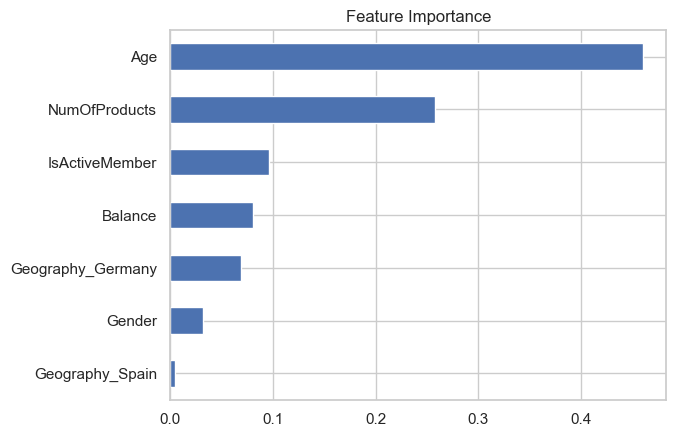

In [20]:
#Feature Importance:
importance = pd.Series(churn_ml_model.feature_importances_, index=X.columns)
importance.sort_values().plot(kind='barh')
plt.title("Feature Importance")
plt.show()

Feature importance reveals that Age is the most influential predictor of churn, followed by Balance and NumOfProducts. Remaining features (Geography, Gender, IsActiveMember) contribute very little.

### Conclusion:
First, we imported the Churn Modelling dataset which has 10,000 rows and 14 columns. We dropped 3 identifier columns (RowNumber, CustomerId, Surname) as they carry no predictive value. No missing values or duplicates were found. 5 out of 11 columns are binary or categorical in nature.

In the statistical summary, age is slightly right-skewed. Balance shows a large gap between mean and median, suggesting many customers have zero balance. Other features are normally distributed. The target variable (Exited) is imbalanced 80% stayed, 20% churned. Most customers use 1–2 products and are loyal for 1–8 years.

In univariate analysis, age shows outliers above 62. Balance shows a large number of customers with zero balance ignoring these reveals a symmetric distribution. France dominates geography. 1–2 products are most common. Male/female ratio is 55/45. Most customers have a credit card. Active and inactive members are 50/50.

In bivariate analysis, churned customers are significantly older with higher median age. Churned customers also have higher median balance bank lost valuable customers. Germany shows highest churn rate despite fewer customers. 1-product customers show 50% churn rate. 3-product customers show ~90% churn suspicious pattern. Inactive members mostly churn.

In multivariate analysis, Age (0.29) and Balance (0.12) show highest positive correlation with Exited. IsActiveMember (-0.16) shows negative correlation active members less likely to churn.

Three classification models were trained with class_weight='balanced' to handle class imbalance. Decision Tree achieved the highest churn recall (0.82) catching the most churners making it the best model for our objective of identifying customers likely to leave. Random Forest achieved the best balance between recall (0.79) and precision (0.49) with highest accuracy (79%). Logistic Regression improved recall to 0.73 but precision remained low. Overall, Decision Tree is preferred for churn detection as our primary goal is to identify at-risk customers before they leave.

Feature importance confirmed that Age and Balance are the most influential predictors retraining with only these features gave almost the same results.